## Monty Hall Problem

- Simulate three doors, one car, and two goats.
 - Simulate three players: the switcher, the conservative, and the newcomer. 
 - Record who wins.
 - Repeat it many times.
 - Which player do you want to be?

And what if you had $N$ doors to choose from and the presenter opens $p\leq N$ of them? Study how the probability of winning changes as a function of $p$ and $N$.

In [65]:
import numpy as np
import random
import matplotlib.pyplot as plt

Let's start with the simulation involving three doors and three players (conservative, switcher and newcomer) and see which one has the highest probability of winning:

In [ ]:
N_sim = 10000
ndoors = 3
 
win1, win2, win3 = [], [], []
prob1, prob2, prob3 = [], [], []

for i in range(N_sim):
    car = random.randint(1,ndoors)

    door_chosen = random.randint(1,ndoors)
    if door_chosen == car:
        win1.append('win')
    prob1.append(len(win1)/(i+1))
        
    door_pres = random.randint(1,ndoors)
    while door_pres == door_chosen or door_pres == car:
        door_pres = random.randint(1,ndoors)

    door_switch = random.randint(1,ndoors)
    while door_switch == door_chosen or door_switch == door_pres:
        door_switch = random.randint(1,ndoors)
    if door_switch == car:
        win2.append('win')
    prob2.append(len(win2)/(i+1))

    door_new = random.randint(1,ndoors)
    while door_new == door_pres:
        door_new = random.randint(1,ndoors)
    if door_new == car:
        win3.append('win')
    prob3.append(len(win3)/(i+1))

print ('Probability of winning for Conservative = ', prob1[-1])
print ('Probability of winning for Switcher = ', prob2[-1])
print ('Probability of winning for Newcomer = ', prob3[-1])

Probability of winning for Conservative =  0.3247
Probability of winning for Switcher =  0.6753
Probability of winning for Newcomer =  0.4982


So the switcher has the highest probability of winning!

Text(0, 0.5, 'Probability of winning')

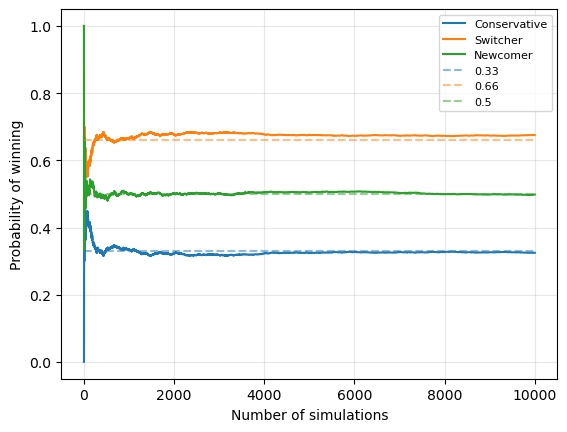

In [67]:
plt.plot(prob1, label='Conservative')
plt.plot(prob2, label='Switcher')
plt.plot(prob3, label='Newcomer')
plt.grid(alpha=0.3)
plt.hlines(0.33, 0, N_sim, colors='C0', linestyles='dashed', label='0.33', alpha=0.5)
plt.hlines(0.66, 0, N_sim, colors='C1', linestyles='dashed', label='0.66', alpha=0.5)
plt.hlines(0.5, 0, N_sim, colors='C2', linestyles='dashed', label='0.5', alpha=0.5)
plt.legend(loc='upper right', fontsize=8)
plt.xlabel('Number of simulations')
plt.ylabel('Probability of winning')

As the number of simulation increases, the probabilities converge to the expected value.

Let's try now with N doors and the presentator opens N-2 of them:

In [ ]:
N_sim = 500 
ndoors = 500   # Maximum number of doors

win1, win2, win3 = np.zeros(ndoors-2), np.zeros(ndoors-2), np.zeros(ndoors-2)

for N_doors in range(3, ndoors+1):
    doors_indices = set(range(N_doors))

    for i in range (N_sim):
        car = random.randint(1,N_doors)

        door_chosen = random.randint(1,N_doors)
        if door_chosen == car:
            win1[N_doors-3] += 1
        
        opened_doors = {car, door_chosen}
        available_doors = list(doors_indices - opened_doors)
        door_pres = set(random.sample(available_doors, N_doors-2))

        closed_doors = list(doors_indices - door_pres)
        switch_options = [d for d in closed_doors if d != door_chosen]
        door_switch = random.choice(switch_options)
        if door_switch == car:
            win2[N_doors-3] += 1
            
        door_new = random.choice(closed_doors)
        if door_new == car:
            win3[N_doors-3] += 1

Text(0, 0.5, 'Probability of winning')

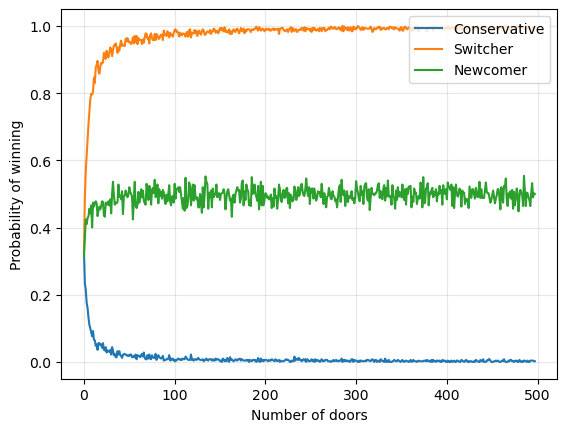

In [69]:
plt.plot(win1/N_sim, label='Conservative')
plt.plot(win2/N_sim, label='Switcher')
plt.plot(win3/N_sim, label='Newcomer')
plt.grid(alpha=0.3)
plt.legend(loc='upper right', fontsize=10)
plt.xlabel('Number of doors')
plt.ylabel('Probability of winning')

The probability of winning of the coservative player decreases with the number of doors, as expected, while the switcher wins almost always!

Lastly, let's look at how the probability changes with the numer of doors opened by the presentator:

In [72]:
N_sim = 500
ndoors = 100   # Number of doors (now fixed)

win1, win2, win3 = np.zeros(ndoors-1), np.zeros(ndoors-1), np.zeros(ndoors-1)

doors_indices = set(range(ndoors))

for n_opened in range(ndoors-1):
    for i in range(N_sim):
        car = random.randint(1,ndoors)

        door_chosen = random.randint(1, ndoors)
        if door_chosen == car:
            win1[n_opened] += 1

        opened_doors = {car, door_chosen}
        available_doors = list(doors_indices - opened_doors)
        door_pres = set(random.sample(available_doors, n_opened))

        closed_doors = list(doors_indices - door_pres)
        switch_options = [d for d in closed_doors if d != door_chosen]
        door_switch = random.choice(switch_options)
        if door_switch == car:
            win2[n_opened] += 1

        door_new = random.choice(closed_doors)
        if door_new == car:
            win3[n_opened] += 1

Text(0, 0.5, 'Probability of winning')

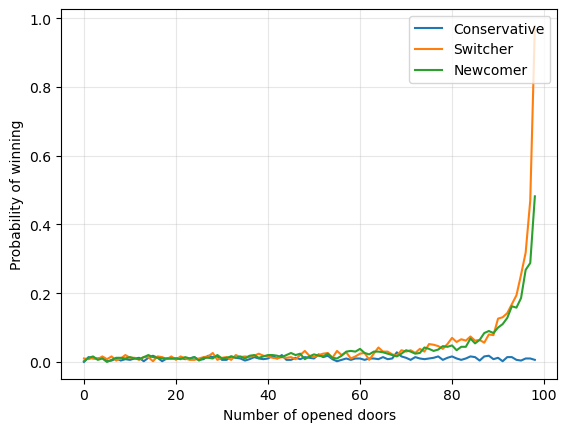

In [73]:
plt.plot(win1/N_sim, label='Conservative')
plt.plot(win2/N_sim, label='Switcher')
plt.plot(win3/N_sim, label='Newcomer')
plt.grid(alpha=0.3)
plt.legend(loc='upper right', fontsize=10)
plt.xlabel('Number of opened doors')
plt.ylabel('Probability of winning')

When the number of opened doors il low, all the players have a low probability of winning!